In [1]:
# Libraries
import pandas as pd
import geopandas as gpd
import numpy as np 
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform # Reprojection
from rasterio import features # Rasterizing
from rasterio.enums import MergeAlg # Rasterizing while retaining attributes
np.set_printoptions(suppress = True) # Turn off scientific notation
from rio_cogeo.cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles
from rio_cogeo import cog_validate, cog_info

In [7]:
# Only run initially!!

# Unzip the zipped folders in the main zip file

#from zipfile import ZipFile

#tracts_zip = './data/svi/cb_2022_us_all_500k.zip'
#tracts_out = './data/svi/main_census_unzipped'

#with ZipFile(tracts_zip, 'r') as zObject:
    # Extract ALL census zipped files and store in data > svi > main_census_unzipped folder
#    zObject.extractall(path = tracts_out)

In [3]:
# Only run initially!!

#from zipfile import ZipFile

# Unzip the specifics tracts folder 

#counties_zip = './data/svi/cb_2022_us_county_500k.zip'
#counties_out = './data/svi'

#with ZipFile(counties_zip, 'r') as zObject:
    # Extract downloaded 2022 census tracts data and store in data > svi folder
#    zObject.extractall(path = counties_out)

In [2]:
# Read in counties

counties_path = './data/svi/cb_2022_us_county_500k.shp'

counties = gpd.read_file(counties_path)[['GEOID', 'STATE_NAME', 'geometry']]

print(f'Rows: {counties.shape[0]}') # Shape
print(f'CRS: {counties.crs}') # CRS

counties.head(2)

Rows: 3235
CRS: EPSG:4269


,GEOID,STATE_NAME,geometry
0,01069,Alabama,"POLYGON ((-85.71209 31.19727, -85.70934 31.198..."
1,01023,Alabama,"POLYGON ((-88.47323 31.89386, -88.46888 31.930..."


In [3]:
# Extract only CONUS from counties

# All current states
counties['STATE_NAME'].unique()

# States to remove
remove_states = ['Alaska', 'Hawaii', 'Puerto Rico', 'United States Virgin Islands', 'American Samoa', 'Guam', 'Commonwealth of the Northern Mariana Islands']

# Retain states not in above list
counties = counties[~counties['STATE_NAME'].isin(remove_states)]

print(f'Rows: {counties.shape[0]}') # Shape

Rows: 3109


In [ ]:
# Create dissolved CONUS extent: start #############################################################################################

In [11]:
# Dissolve based on counties to save out CONUS shp
conus_dissolved = counties.dissolve()

conus_dissolved = conus_dissolved[['geometry']]

conus_dissolved['Name'] = 'CONUS'

conus_dissolved.head()

,geometry,Name
0,"MULTIPOLYGON (((-118.55845 33.00683, -118.5527...",CONUS


<Axes: >

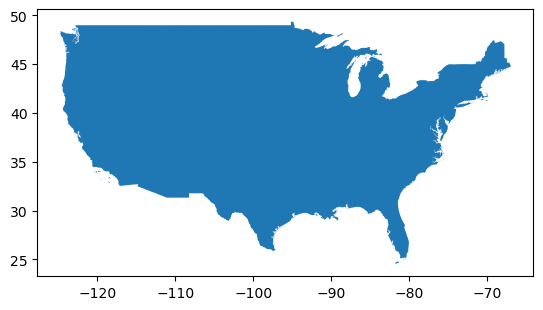

In [12]:
conus_dissolved.plot()

In [13]:
# Save out CONUS shp
conus_dissolved.to_file('./data/CONUS shp/CONUS.shp')

In [ ]:
# Create dissolved CONUS extent: end #############################################################################################

In [4]:
# Read in SVI data

svi_path = './data/svi/SVI_2022_US_county.csv'

svi_table = pd.read_csv(svi_path, usecols = ['STATE', 'FIPS', 'RPL_THEMES'])

print(f'Rows: {svi_table.shape[0]}') # Shape

svi_table.head(2)

Rows: 3144


,STATE,FIPS,RPL_THEMES
0,Alabama,1001,0.2663
1,Alabama,1003,0.3487


In [5]:
# Check for null values - none!
svi_table.isnull().values.any()

False

In [6]:
# Extract only CONUS from svi table data

# All current states
svi_table['STATE'].unique()

# States to remove
remove_states = ['Alaska', 'Hawaii']

# Retain states not in above list
svi_table = svi_table[~svi_table['STATE'].isin(remove_states)]

print(f'Rows: {svi_table.shape[0]}') # Shape

Rows: 3109


In [7]:
# Merge SVI data to the counties

# Create merge cols
counties['FIPS'] = counties['GEOID'].astype('int64') # Add FIPS col to match svi_table and change datatype

# Check that both dataframes have the same unique GEOIDs
print(f"Both dataframes have the same number of unique FIPS: {counties['FIPS'].nunique() == svi_table['FIPS'].nunique()}")
print(f"Both dataframes have the same unique FIPS: {set(svi_table['FIPS'].unique()) == set(counties['FIPS'].unique())}")

# Merge
svi_counties = pd.merge(left = counties, right = svi_table, how = 'left', on = 'FIPS')

print(f'Rows: {svi_counties.shape[0]}') # Shape

svi_counties.head()

Both dataframes have the same number of unique FIPS: True
Both dataframes have the same unique FIPS: True
Rows: 3109


,GEOID,STATE_NAME,geometry,FIPS,STATE,RPL_THEMES
0,01069,Alabama,"POLYGON ((-85.71209 31.19727, -85.70934 31.198...",1069,Alabama,0.7175
1,01023,Alabama,"POLYGON ((-88.47323 31.89386, -88.46888 31.930...",1023,Alabama,0.6548
2,01005,Alabama,"POLYGON ((-85.74803 31.61918, -85.74544 31.618...",1005,Alabama,0.9927
3,01107,Alabama,"POLYGON ((-88.34043 32.9912, -88.33101 33.0724...",1107,Alabama,0.8918
4,01033,Alabama,"POLYGON ((-88.13925 34.5878, -88.13872 34.5892...",1033,Alabama,0.4467


In [8]:
# Reproject svi_counties to NAD 83 CONUS Albers (epsg:5070)

svi_counties = svi_counties.to_crs('epsg:5070')
print(f'CRS: {svi_counties.crs}')

CRS: epsg:5070


In [9]:
# Print min and max SVI values
print(f"Min: {svi_counties['RPL_THEMES'].min()}")
print(f"Min: {svi_counties['RPL_THEMES'].max()}")

# Check for null values - none!
svi_counties.isnull().values.any()

Min: 0.0
Min: 1.0


False

In [10]:
# Rasterize svi values matching dist to gwt raster - (5 minutes) this code works!!!!!
dist_gwt_REF = './data/SSURGO_raw/dist_GWT/gwt_inches.tif'
svi_raster = 'data/svi/svi_raw_rasterized.tif'

geom_value = list(zip(svi_counties.geometry, svi_counties['RPL_THEMES']))

with rasterio.open(dist_gwt_REF) as ref:
    # Copy profile
    profile = ref.profile.copy()
    
    # Update profile
    profile.update(compress = 'lzw')
        
    # Rasterize 
    rasterized = features.rasterize(
        geom_value,
        out_shape = ref.shape,
        transform = ref.transform,
        fill = -10, # Background fill
        all_touched = True,
        merge_alg = MergeAlg.replace,
        dtype = rasterio.float32
    )
    
    with rasterio.open(svi_raster, 'w', **profile) as dst:
        dst.write(rasterized, 1)


In [11]:
# Verify rasterization (WITH MASKING)

svi_raster = 'data/svi/svi_raw_rasterized.tif'

with rasterio.open(svi_raster, mode = 'r') as src:
    print(f'Profile: {src.profile}')
    print(f'Nodata: {src.nodata}')
    print(f'CRS: {src.crs}')
    print(f'Resolution {src.res}')
   
    # Check min and max rescaled values:
    
    # Set initial global min and max
    global_min = np.inf 
    global_max = -np.inf 
    
    # Set total_nodata
    total_nodata = 0

    for ji, window in src.block_windows(1):
        data = src.read(1, window = window, masked = True)
        
        # Get local min and max for each window
        local_min = data.min()
        local_max = data.max()
        
        # Get global min and max by comparing the initial global min and max to each local min and max for all windows
        global_min = min(global_min, local_min) # Compares global_min to window min
        global_max = max(global_max, local_max) # Compared global_max to window max
        
        # Count nodata cells
        total_nodata += np.sum(data.mask)
        
    # Print the min and max rescaled values
    print(f'Min: {global_min}')
    print(f'Max: {global_max}')
    
    # % nodata cells
    total_cells = src.width * src.height
    percent_nodata = (total_nodata / total_cells) 
    print(f'% nodata cells: {percent_nodata}')

Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 153996, 'height': 96751, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, -2356125.0,
       0.0, -30.0, 3172575.0), 'blockxsize': 128, 'blockysize': 128, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
Nodata: -10.0
CRS: EPSG:5070
Resolu

In [2]:
# Remove "excess" cells 
hsg_final_composite = './data/SSURGO_raw/hsg/hsg_FINAL_composite.tif' 
svi_raster = 'data/svi/svi_raw_rasterized.tif'
svi_MATCH = 'data/svi/svi_MATCH.tif'

# Open hsg composite raster - want conus cells to match THIS raster
with rasterio.open(hsg_final_composite) as conus:

    # Nodata value for the conus raster
    conus_nodata = conus.nodata 
    # Profile conus raster
    profile = conus.profile.copy()
    profile.update(dtype = rasterio.float32)

    # Open raster - want to convert any cells containing data where conus contains NODATA to nodata
    with rasterio.open(svi_raster) as src:
        
        src_nodata = src.nodata # Nodata value 
        
        # Open output raster
        with rasterio.open(svi_MATCH, 'w', **profile) as dst:
        
            for ji, window in conus.block_windows(1):
            
                # hsg composite raster data
                conus_data = conus.read(1, window = window)
            
                # Land cover raster data
                src_data = src.read(1, window = window)
            
                # Identify cells where conus_data == nodata value
                remove_mask = (conus_data == conus_nodata)
            
                # Convert cells in src where conus is nodata to the nodata value
                src_data[remove_mask] = src_nodata
            
                # Write out
                dst.write(src_data, 1, window = window)

In [3]:
# Verify match raster (WITH MASKING)

svi_MATCH = './data/svi/svi_MATCH.tif'

with rasterio.open(svi_MATCH, mode = 'r') as src:
    print(f'Profile: {src.profile}')
    print(f'Nodata: {src.nodata}')
    print(f'CRS: {src.crs}')
    print(f'Resolution {src.res}')
   
    # Check min and max rescaled values:
    
    # Set initial global min and max
    global_min = np.inf 
    global_max = -np.inf 
    
    # Set total_nodata
    total_nodata = 0

    for ji, window in src.block_windows(1):
        data = src.read(1, window = window, masked = True)
        
        # Get local min and max for each window
        local_min = data.min()
        local_max = data.max()
        
        # Get global min and max by comparing the initial global min and max to each local min and max for all windows
        global_min = min(global_min, local_min) # Compares global_min to window min
        global_max = max(global_max, local_max) # Compared global_max to window max
        
        # Count nodata cells
        total_nodata += np.sum(data.mask)
        
    # Print the min and max rescaled values
    print(f'Min: {global_min}')
    print(f'Max: {global_max}')
    
    # % nodata cells
    total_cells = src.width * src.height
    percent_nodata = (total_nodata / total_cells) 
    print(f'% nodata cells: {percent_nodata}')

Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 153996, 'height': 96751, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, -2356125.0,
       0.0, -30.0, 3172575.0), 'blockxsize': 128, 'blockysize': 128, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
Nodata: -10.0
CRS: EPSG:5070
Resolu

In [2]:
# Apply min-max scaling  

svi_MATCH = './data/svi/svi_MATCH.tif'
svi_standardized = './data/svi/svi_standardized.tif'

with rasterio.open(svi_MATCH, mode = 'r') as src:
    profile = src.profile.copy()
    
    # Set initial global min and max
    global_min = np.inf # Highest possible number so anythign will automatically be less
    global_max = -np.inf # Lowest possible number so anything will automatically be greater
    
    for ji, window in src.block_windows(1):
        data = src.read(1, window = window, masked = True)
        
        # Get local min and max for each window
        local_min = data.min()
        local_max = data.max()
        
        # Get global min and max by comparing the initial global min and max to each local min and max for all windows
        global_min = min(global_min, local_min) # Compares global_min to window min
        global_max = max(global_max, local_max) # Compared global_max to window max
        
    # Sanity check: make sure min and max are reasonable values
    print(f'Global min: {global_min}')
    print(f'Global max: {global_max}')
    
    with rasterio.open(svi_standardized, mode = 'w', **profile) as dst:
        for ji, window in src.block_windows(1):
            data = src.read(1, window = window, masked = True)
            
            # Apply min-max scaling
            rescaled = ((data - global_min) / (global_max - global_min) * 10)
            
            # Fill masked (nodata values) with the nodata value
            rescaled_filled = rescaled.filled(src.nodata)
            
            # Write out raster
            dst.write(rescaled_filled.astype(np.float32), 1, window = window)

Global min: 0.0
Global max: 1.0


In [4]:
# Verify min-max scaling

svi_standardized = './data/svi/svi_standardized.tif'

with rasterio.open(svi_standardized, mode = 'r') as src:
    print(f'Profile: {src.profile}')
    print(f'Nodata: {src.nodata}')
    print(f'CRS: {src.crs}')
    print(f'Resolution {src.res}')
   
    # Check min and max rescaled values:
    
    # Set initial global min and max
    global_min = np.inf 
    global_max = -np.inf 
    
    # Set total_nodata
    total_nodata = 0

    for ji, window in src.block_windows(1):
        data = src.read(1, window = window, masked = True)
        
        # Get local min and max for each window
        local_min = data.min()
        local_max = data.max()
        
        # Get global min and max by comparing the initial global min and max to each local min and max for all windows
        global_min = min(global_min, local_min) # Compares global_min to window min
        global_max = max(global_max, local_max) # Compared global_max to window max
        
        # Count nodata cells
        total_nodata += np.sum(data.mask)
        
    # Print the min and max rescaled values
    print(f'Min: {global_min}')
    print(f'Max: {global_max}')
    
    # % nodata cells
    total_cells = src.width * src.height
    percent_nodata = (total_nodata / total_cells) 
    print(f'% nodata cells: {percent_nodata}')

Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 153996, 'height': 96751, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, -2356125.0,
       0.0, -30.0, 3172575.0), 'blockxsize': 128, 'blockysize': 128, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
Nodata: -10.0
CRS: EPSG:5070
Resolu

In [12]:
# Save out preprocessed dist GWT as cloud optimized GeoTiff - save to scratch (8:55 AM)

svi_raster = 'data/svi/svi_raw_rasterized.tif'
cog_out_svi_raw_viewing = '/scratch/bfqp/cchan2/rasters/svi_RAW_VIEWING.tif' # SAVE TO SCRATCH

profile = cog_profiles.get('lzw')

profile.update(
    compress = 'DEFLATE',
    predictor = 3, # 2 for integer; 3 for float
    tiled = True,
    blockxsize = 512,
    blockysize = 512, 
    bigtiff = 'YES')

cog_translate(
    svi_raster, # dont include argument
    cog_out_svi_raw_viewing, # dont include argument
    profile, # dont include argument
    overview_resampling = 'bilinear', # Change based on data values
    nodata = -10,
    use_cog_driver = True,
    in_memory = False, 
    web_optimized = True)

Reading input: data/svi/svi_raw_rasterized.tif

Adding overviews...
Updating dataset tags...
Writing output to: /scratch/bfqp/cchan2/rasters/svi_RAW_VIEWING.tif


In [14]:
# Validate cogeo raster
cog_validate(cog_out_svi_raw_viewing)

(True, [], [])

In [15]:
# Copy from scratch back into projects folder
import shutil

cog_out_svi_raw_viewing = '/scratch/bfqp/cchan2/rasters/svi_RAW_VIEWING.tif' 
cog_out_svi_raw_viewing_PROJECTS = '/projects/bfqp/cchan2/data/svi/svi_RAW_VIEWING.tif'

shutil.copy(cog_out_svi_raw_viewing, cog_out_svi_raw_viewing_PROJECTS)

'/projects/bfqp/cchan2/data/svi/svi_RAW_VIEWING.tif'

In [16]:
# Check cogeo raster

cog_out_svi_raw_viewing_PROJECTS = './data/svi/svi_RAW_VIEWING.tif'

with rasterio.open(cog_out_svi_raw_viewing_PROJECTS, mode = 'r') as src:
    print(f'Profile: {src.profile}')
    print(f'Nodata: {src.nodata}')
    print(f'CRS: {src.crs}')
    print(f'Resolution {src.res}')
   
    # Check min and max rescaled values:
    
    # Set initial global min and max
    global_min = np.inf 
    global_max = -np.inf 
    
    # Set total_nodata
    total_nodata = 0

    for ji, window in src.block_windows(1):
        data = src.read(1, window = window, masked = True)
        
        # Get local min and max for each window
        local_min = data.min()
        local_max = data.max()
        
        # Get global min and max by comparing the initial global min and max to each local min and max for all windows
        global_min = min(global_min, local_min) # Compares global_min to window min
        global_max = max(global_max, local_max) # Compared global_max to window max
        
        # Count nodata cells
        total_nodata += np.sum(data.mask)
        
    # Print the min and max rescaled values
    print(f'Min: {global_min}')
    print(f'Max: {global_max}')
    
    # % nodata cells
    total_cells = src.width * src.height
    percent_nodata = (total_nodata / total_cells) 
    print(f'% nodata cells: {percent_nodata}')

Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 182784, 'height': 107776, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'), 'transform': Affine(38.2185141425881, 0.0, -14245416.087451734,
       0.0, -38.2185141425881, 6731350.458905771), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': '